Shape: (108428, 17)
Index(['HR', 'HRV_RMSSD', 'HRV_SDNN', 'RR_mean', 'RR_std', 'RR_min', 'RR_max',
       'RR_count', 'RR_diff_std', 'RR_valid', 'EDA_Tonic', 'EDA_Phasic',
       'SCR_Count', 'participant', 'time_sec', 'EDA_Tonic_log',
       'EDA_Phasic_log'],
      dtype='str')

=== DESCRIBE ===
                  HR      HRV_RMSSD       HRV_SDNN        RR_mean  \
count  108428.000000  108428.000000  108428.000000  108428.000000   
mean       79.283488      54.870827      63.313658     772.415251   
std        11.097128      22.455123      31.007067     106.814237   
min        52.596467       6.833602       9.829522     424.857143   
25%        71.396398      36.801615      41.726876     698.372093   
50%        78.343750      53.488340      56.681599     767.051282   
75%        86.078315      71.789239      77.275378     841.027778   
max       141.215822     133.037076     200.000000    1142.115385   

              RR_std         RR_min         RR_max       RR_count  \
count  108

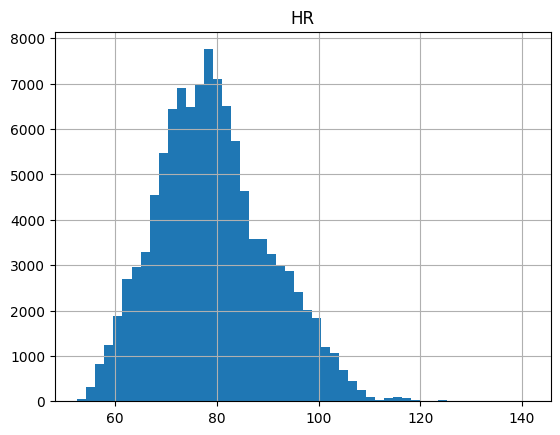

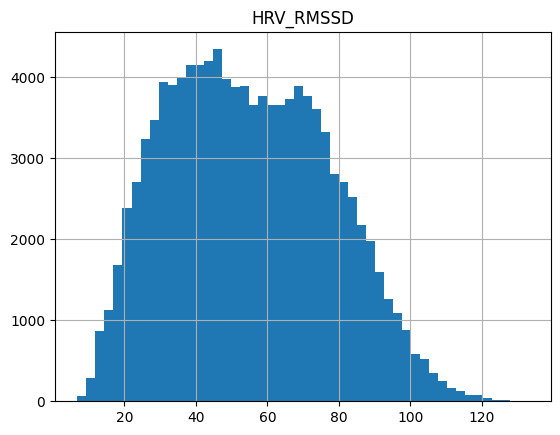

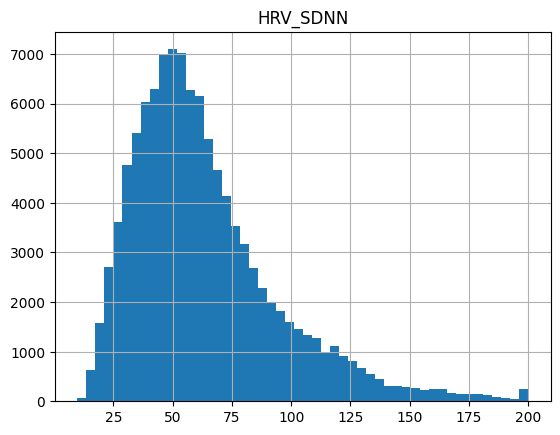

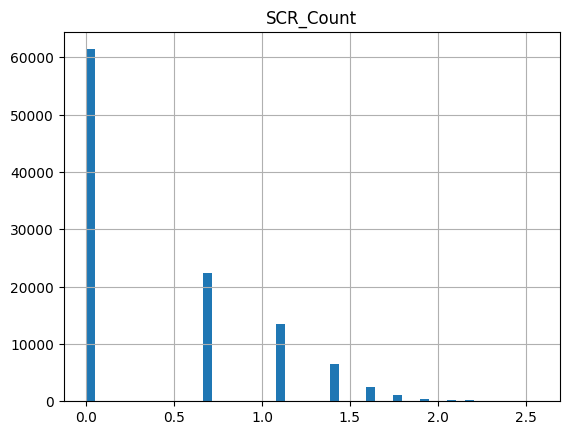

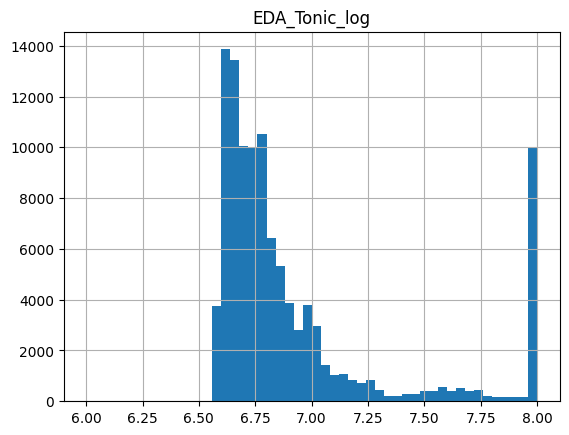

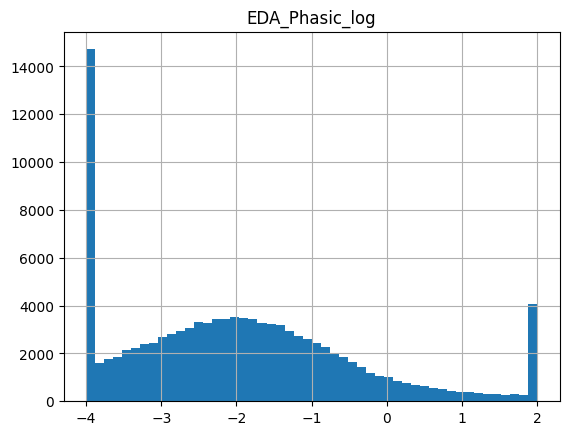


=== RANGE FLAGS ===
HR < 40: 0.0
HR > 150: 0.0
RMSSD > 120: 0.0007562622200907515
RMSSD < 10: 0.0008669347401040322
SDNN > 120: 0.05991994687719039
SDNN < 10: 3.68908400044269e-05
SCR == 0: 0.5664680709779761


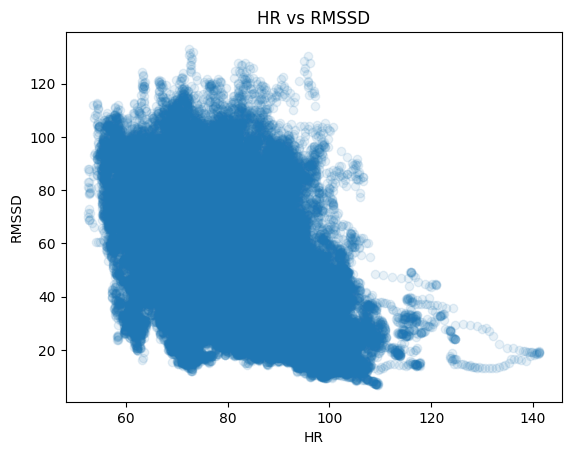


=== HRV NaN ratio ===
0.0

=== EXTREME RMSSD (>120) ===
             HR   HRV_RMSSD    HRV_SDNN     RR_mean      RR_std  RR_min  \
8259  95.804402  120.441895  130.869122  616.630435  129.438815   345.0   
8262  95.811865  120.956475  138.702929  617.173913  137.187004   345.0   
8263  95.553367  123.592071  141.826381  619.777778  140.241679   345.0   
8264  95.042461  128.500973  150.940090  620.978261  149.290422   345.0   
8265  95.729457  130.536030  152.340080  619.333333  150.637903   345.0   

      RR_max  RR_count  RR_diff_std  RR_valid  EDA_Tonic  EDA_Phasic  \
8259  1085.0        46   117.161895         1  50.335922   -0.187446   
8262  1085.0        46   114.842687         1  50.195771    0.028728   
8263  1085.0        45   115.993774         1  50.135950    0.025299   
8264  1085.0        46   123.595330         1  50.065435   -0.015857   
8265  1085.0        45   125.708220         1  49.981886   -0.034936   

      SCR_Count participant  time_sec  EDA_Tonic_log  EDA_P

In [8]:
# Feature Validity Check Notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# LOAD DATA
# =========================
FILE_PATH = Path("../data/features_extraction_full_file_analys.csv")  # ändra

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.columns)

# =========================
# BASIC STATS
# =========================
print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== NaN CHECK ===")
print(df.isna().mean())

# =========================
# HISTOGRAMS
# =========================
features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Count",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

for f in features:
    plt.figure()
    df[f].hist(bins=50)
    plt.title(f)
    plt.show()

# =========================
# RANGE CHECKS
# =========================
print("\n=== RANGE FLAGS ===")

print("HR < 40:", (df["HR"] < 40).mean())
print("HR > 150:", (df["HR"] > 150).mean())

print("RMSSD > 120:", (df["HRV_RMSSD"] > 120).mean())
print("RMSSD < 10:", (df["HRV_RMSSD"] < 10).mean())

print("SDNN > 120:", (df["HRV_SDNN"] > 120).mean())
print("SDNN < 10:", (df["HRV_SDNN"] < 10).mean())

print("SCR == 0:", (df["SCR_Count"] == 0).mean())

# =========================
# HR vs RMSSD
# =========================
plt.figure()
plt.scatter(df["HR"], df["HRV_RMSSD"], alpha=0.1)
plt.xlabel("HR")
plt.ylabel("RMSSD")
plt.title("HR vs RMSSD")
plt.show()


# =========================
# WINDOW QUALITY
# =========================
print("\n=== HRV NaN ratio ===")
print(df["HRV_RMSSD"].isna().mean())

# =========================
# EXTREME VALUES SAMPLE
# =========================
print("\n=== EXTREME RMSSD (>120) ===")
print(df[df["HRV_RMSSD"] > 120].head())

print("\n=== EXTREME HR (<40 or >150) ===")
print(df[(df["HR"] < 40) | (df["HR"] > 150)].head())

# =========================
# SUMMARY FLAGS
# =========================
print("\n=== QUICK SUMMARY ===")
print({
    "high_rmssd_ratio": float((df["HRV_RMSSD"] > 120).mean()),
    "low_hr_ratio": float((df["HR"] < 40).mean()),
    "high_hr_ratio": float((df["HR"] > 150).mean()),
    "scr_zero_ratio": float((df["SCR_Count"] == 0).mean()),
    "nan_ratio": float(df["HRV_RMSSD"].isna().mean())
})



=== RR DESCRIBE ===
             RR_mean         RR_std         RR_min         RR_max  \
count  108428.000000  108428.000000  108428.000000  108428.000000   
mean      772.415251      62.503440     633.108883     924.111254   
std       106.814237      30.697477     129.364911     147.000136   
min       424.857143       9.738082     305.000000     460.000000   
25%       698.372093      41.199121     560.000000     830.000000   
50%       767.051282      55.946375     645.000000     915.000000   
75%       841.027778      76.199321     715.000000    1010.000000   
max      1142.115385     239.737845    1005.000000    1495.000000   

            RR_count    RR_diff_std  RR_valid  
count  108428.000000  108428.000000  108428.0  
mean       39.567879      54.608549       1.0  
std         5.555503      22.211801       0.0  
min        26.000000       6.832951       1.0  
25%        36.000000      36.740709       1.0  
50%        39.000000      53.308797       1.0  
75%        43.000000 

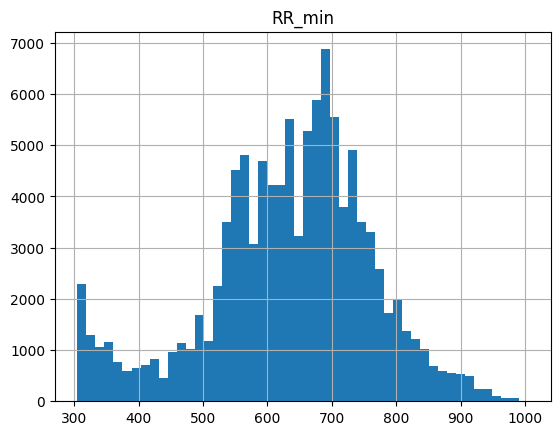

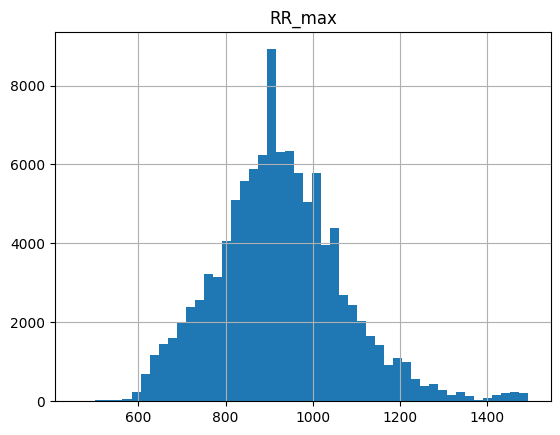

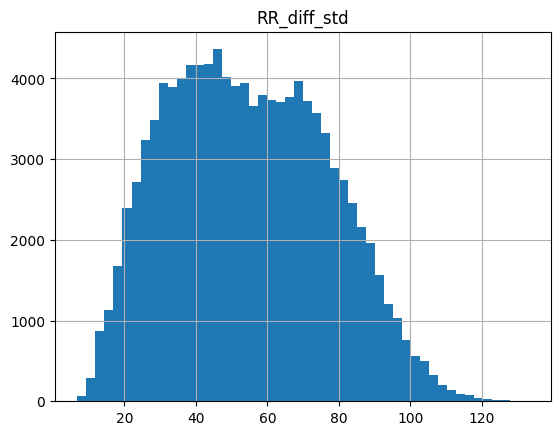


=== HR vs RR consistency ===
Mean error (bpm): 0.18372566983632715
Median error (bpm): 0.0973302682463526


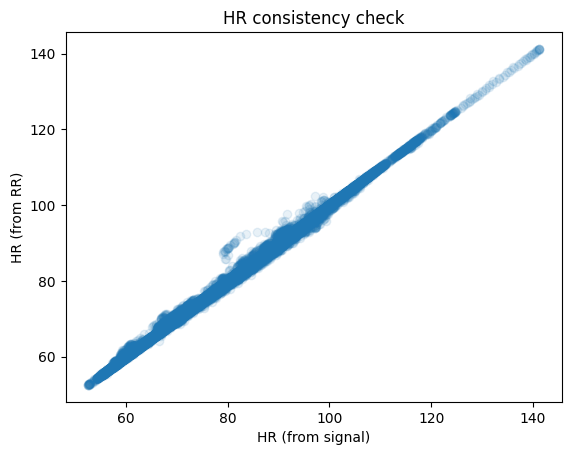


=== BAD WINDOWS SAMPLE ===
Number of bad windows: 2016
Ratio: 0.01859298336223116

Sample:
           HR   HRV_RMSSD    HRV_SDNN     RR_mean      RR_std  RR_min  RR_max  \
19  87.361536  100.560927  142.729175  685.681818  141.097931   340.0   960.0   
20  89.541797  103.154782  142.661215  675.222222  141.067185   340.0   960.0   
21  90.392863  102.328941  141.528275  671.444444  139.946904   340.0   960.0   
34  93.111561  101.145228  184.570693  662.717391  182.553466   340.0  1220.0   
35  93.336109  102.636540  186.780407  654.456522  184.739029   340.0  1220.0   

    RR_count  RR_diff_std  RR_valid    EDA_Tonic  EDA_Phasic  SCR_Count  \
19        44   100.558985         1   546.822681   12.494267   0.000000   
20        45   102.726155         1   555.304420   14.085643   0.000000   
21        45   102.001323         1   564.408531   14.316992   0.000000   
34        46   100.839588         1  1036.408770  221.292060   0.693147   
35        46   102.431683         1  1083.5036

In [9]:
# =========================
# RR / IBI VALIDITY CHECK
# =========================

rr_features = [
    "RR_mean",
    "RR_std",
    "RR_min",
    "RR_max",
    "RR_count",
    "RR_diff_std",
    "RR_valid"
]

print("\n=== RR DESCRIBE ===")
print(df[rr_features].describe())

# -------------------------
# Range checks
# -------------------------
print("\n=== RR RANGE FLAGS ===")

print("RR_min < 300 ms:", (df["RR_min"] < 300).mean())
print("RR_max > 1500 ms:", (df["RR_max"] > 1500).mean())

print("RR_diff_std > 100:", (df["RR_diff_std"] > 100).mean())

print("RR_valid == 0:", (df["RR_valid"] == 0).mean())

# -------------------------
# Histograms
# -------------------------
import matplotlib.pyplot as plt

for f in ["RR_min", "RR_max", "RR_diff_std"]:
    plt.figure()
    df[f].hist(bins=50)
    plt.title(f)
    plt.show()

# -------------------------
# HR consistency check
# -------------------------
df["HR_from_RR"] = 60000 / df["RR_mean"]

error = np.abs(df["HR"] - df["HR_from_RR"])

print("\n=== HR vs RR consistency ===")
print("Mean error (bpm):", error.mean())
print("Median error (bpm):", np.median(error))

plt.figure()
plt.scatter(df["HR"], df["HR_from_RR"], alpha=0.1)
plt.xlabel("HR (from signal)")
plt.ylabel("HR (from RR)")
plt.title("HR consistency check")
plt.show()

# -------------------------
# Problematic windows
# -------------------------
print("\n=== BAD WINDOWS SAMPLE ===")

bad_windows = df[
    (df["RR_min"] < 300) |
    (df["RR_max"] > 1500) |
    (df["RR_diff_std"] > 100)
]

print("Number of bad windows:", len(bad_windows))
print("Ratio:", len(bad_windows) / len(df))

print("\nSample:")
print(bad_windows.head())

<Axes: >

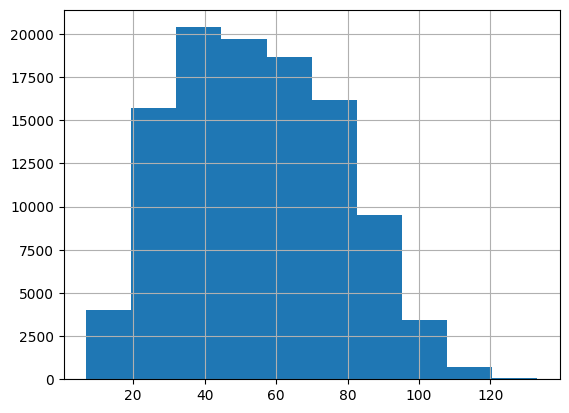

In [10]:
df["HRV_RMSSD"].describe()
df["HRV_RMSSD"].hist()

In [11]:
df["HRV_RMSSD"].describe()

count    108428.000000
mean         54.870827
std          22.455123
min           6.833602
25%          36.801615
50%          53.488340
75%          71.789239
max         133.037076
Name: HRV_RMSSD, dtype: float64